In [26]:
# STEP 1: Import all required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [27]:
# STEP 2: Load dataset and preprocess

def load_and_prepare_mnist(csv_file):
    df = pd.read_csv(csv_file)

    # Separate labels and features
    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    # Normalize pixel values (0–255 → 0–1)
    X = X / 255.0

    # Split dataset into train and test
    return train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# STEP 3: Load your dataset

X_train, X_test, y_train, y_test = load_and_prepare_mnist("mnist_dataset.csv")

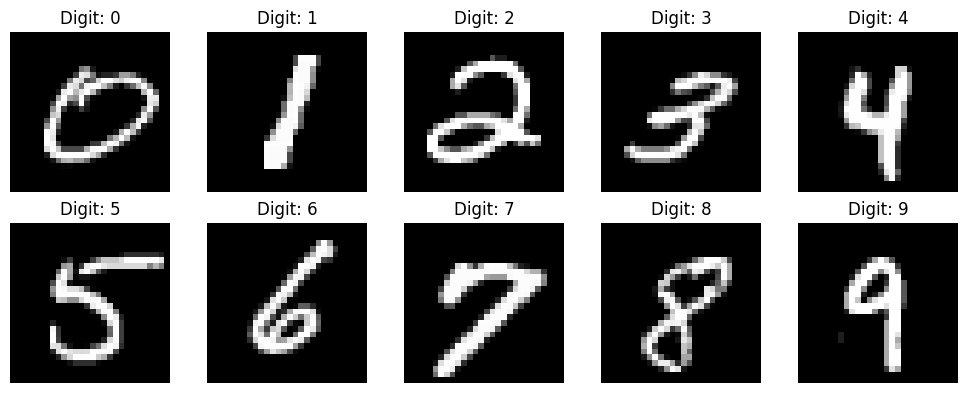

In [29]:
# STEP 4: Plot one sample image per digit (0–9)

def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call function
plot_sample_images(X_train, y_train)

In [30]:
# STEP 5: Convert labels to one-hot encoding

encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))

In [31]:
# STEP 6: Ensure X and y match

assert len(X_train) == len(y_train), "Mismatch in X and y"
print("Shapes are correct!")

Shapes are correct!


In [32]:
# STEP 7: Softmax function

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [33]:
# STEP 8: Predict class labels

def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

In [34]:
# STEP 9: Cross-entropy loss

def loss_softmax(y_pred, y):
    epsilon = 1e-9
    return -np.sum(y * np.log(y_pred + epsilon)) / y.shape[0]

In [35]:
# STEP 10: Average cost over dataset

def cost_softmax(X, y, W, b):
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return loss_softmax(y_pred, y)

In [36]:
# STEP 11: Compute gradients

def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [37]:
# STEP 12: Train model using gradient descent

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return W, b, cost_history

In [38]:
# STEP 13: Initialize weights and bias

d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

In [39]:
# STEP 14: Train model

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b,
    alpha=0.1,
    n_iter=1000,
    show_cost=True
)

Iteration 0, Cost: 2.2107616572526254
Iteration 100, Cost: 0.6066992762112846
Iteration 200, Cost: 0.48938515863222326
Iteration 300, Cost: 0.4409203479158323
Iteration 400, Cost: 0.4128976062968196
Iteration 500, Cost: 0.39405281532134634
Iteration 600, Cost: 0.3802387477350129
Iteration 700, Cost: 0.36953216152172325
Iteration 800, Cost: 0.36090479268596687
Iteration 900, Cost: 0.35375066984360015


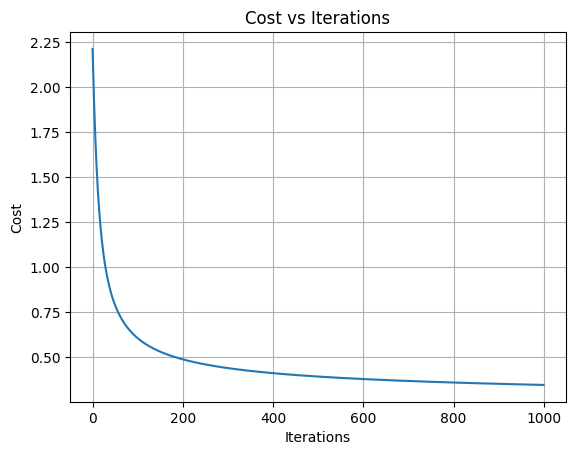

In [41]:
# STEP 15: Plot cost vs iterations

plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid()
plt.show()


In [42]:
# STEP 16: Evaluate performance

y_pred = predict_softmax(X_test, W_opt, b_opt)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
 [[1127    0    5    2    3   11    9    2   13    3]
 [   0 1273    7   11    1    5    1    4   19    1]
 [   1   14 1028   16   19    4   26   25   34    7]
 [   8    5   34 1052    1   53    9    8   28   21]
 [   1    5    7    1 1092    0   10    4    4   52]
 [  22   14   12   43   12  922   14    7   43   15]
 [   6    2    9    1   11   16 1120    2   10    0]
 [   7   26   26    5   15    3    0 1182    7   28]
 [   9   27   13   35    9   32   13    7 1000   15]
 [   8    6   10   18   44    9    0   38   10 1051]]
Precision: 0.9035812248415999
Recall: 0.9039166666666667
F1 Score: 0.9036095871879513


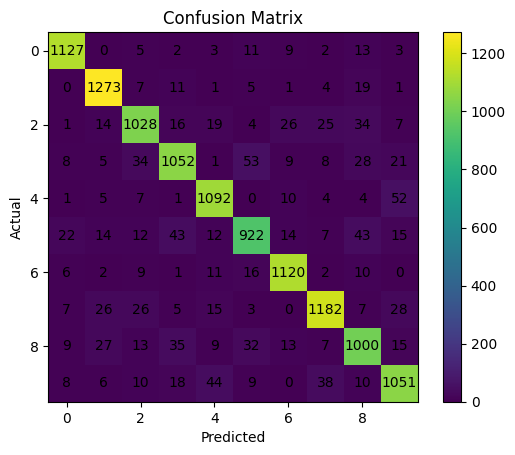

In [43]:
# STEP 17: Visualize confusion matrix

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [44]:
# STEP 18: Logistic regression comparison

from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

# Linear dataset
X_lin, y_lin = make_classification(n_samples=200, n_features=2, n_informative=2,
                                  n_redundant=0, n_clusters_per_class=1, random_state=42)

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2)

model_lin = LogisticRegression()
model_lin.fit(X_train_lin, y_train_lin)

# Non-linear dataset
X_non, y_non = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

X_train_non, X_test_non, y_train_non, y_test_non = train_test_split(X_non, y_non, test_size=0.2)

model_non = LogisticRegression()
model_non.fit(X_train_non, y_train_non)

LogisticRegression()

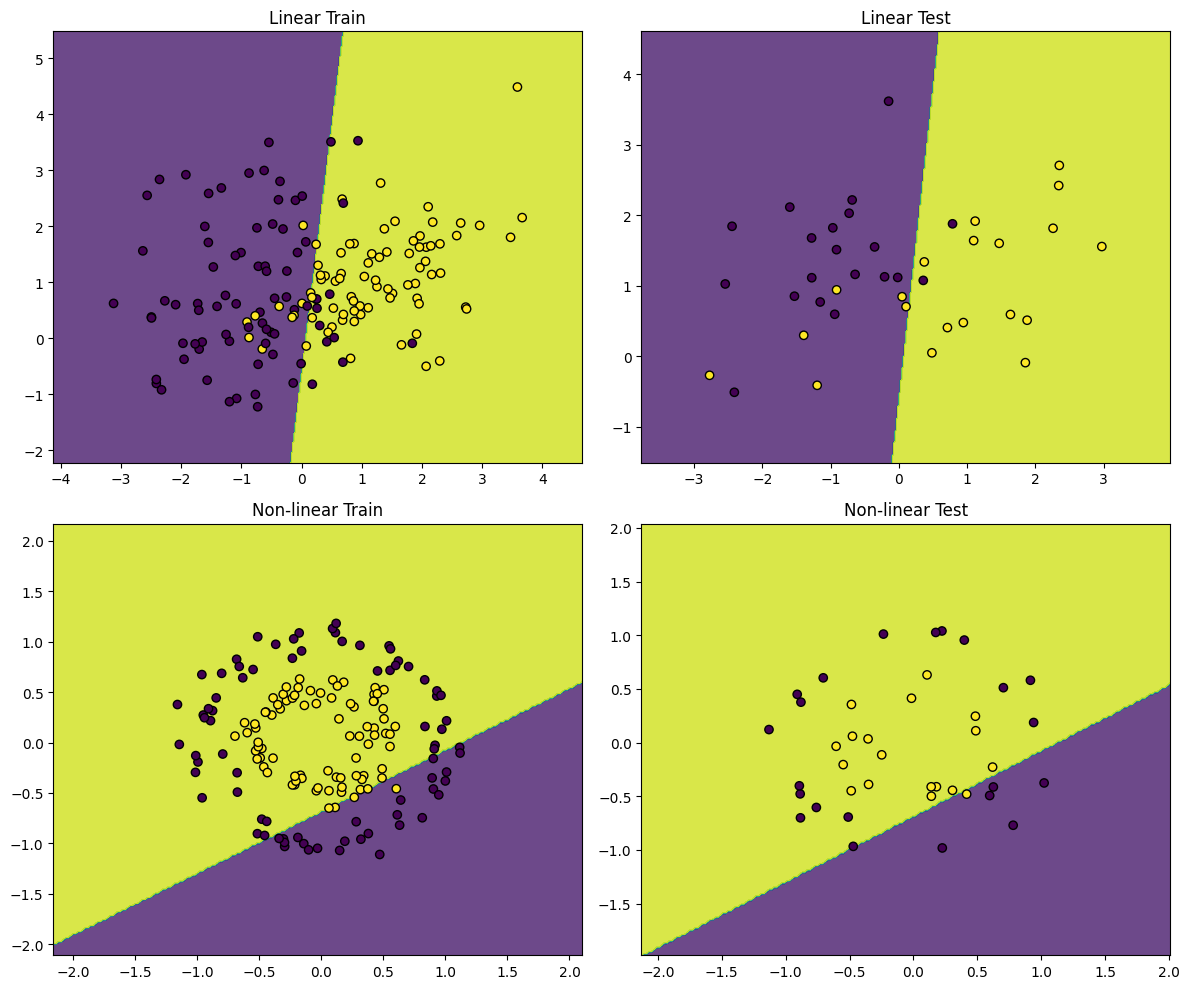

In [45]:
# STEP 19: Plot decision boundaries

def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(axes[0,0], model_lin, X_train_lin, y_train_lin, "Linear Train")
plot_decision_boundary(axes[0,1], model_lin, X_test_lin, y_test_lin, "Linear Test")

plot_decision_boundary(axes[1,0], model_non, X_train_non, y_train_non, "Non-linear Train")
plot_decision_boundary(axes[1,1], model_non, X_test_non, y_test_non, "Non-linear Test")

plt.tight_layout()
plt.show()